In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Load cartridges

In [18]:
OUTPUTS = "/data/workspace/phudish/gated-continual-cartridges/outputs"

# (label, phase1_path, phase2_path)
# Convention: no-tag AMD2021 → AMD2022, with-tag AMD2021 → Pepsi

PAIRS = [
    # ── Llama 3.2 3B ──────────────────────────────────────────────────────────
    ("Llama | AMD2021→AMD2022 | toks=512",
     f"{OUTPUTS}/2026-03-24-09-31-09-train_initial/79909b2b-2a9c-407b-8b36-0db0f25f6f3f/cache_last.pt",
     f"{OUTPUTS}/2026-03-24-10-08-43-train_continual/f8f2f4f4-36fd-4d60-82f6-5a5e5bf843fd/cache_last.pt"),
    ("Llama | AMD2021→AMD2022 | toks=1024",
     f"{OUTPUTS}/2026-03-24-00-44-14-train_initial/aeb02668-e686-48c8-95a4-d517be380254/cache_last.pt",
     f"{OUTPUTS}/2026-03-24-01-09-04-train_continual/b7e2c843-6949-4f91-9960-fd6a78fc4085/cache_last.pt"),
    ("Llama | AMD2021→AMD2022 | toks=2048",
     f"{OUTPUTS}/2026-03-24-02-12-40-train_initial/958a3914-b06c-4ad6-9ccd-ab749a98fb78/cache_last.pt",
     f"{OUTPUTS}/2026-03-24-03-29-47-train_continual/1150d4c9-c3f8-4783-97eb-c9d5b7abafca/cache_last.pt"),
    ("Llama | AMD2021→Pepsi2021 | toks=512",
     f"{OUTPUTS}/2026-03-24-02-12-18-train_initial/859804cb-7529-4500-9a4d-a0de831180d8/cache_last.pt",
     f"{OUTPUTS}/2026-03-24-03-31-33-train_continual/c4064a62-4130-4c05-a249-08160ef24e00/cache_last.pt"),
    ("Llama | AMD2021→Pepsi2021 | toks=1024",
     f"{OUTPUTS}/2026-03-24-00-51-52-train_initial/bf6965fb-7360-49e0-b63d-3a144927500b/cache_last.pt",
     f"{OUTPUTS}/2026-03-24-01-10-06-train_continual/1586e9f3-3b55-438b-9682-c16a9d9c158e/cache_last.pt"),
    ("Llama | AMD2021→Pepsi2021 | toks=2048",
     f"{OUTPUTS}/2026-03-24-02-26-39-train_initial/89363b00-cdf7-4ba9-9e02-336358b18f99/cache_last.pt",
     f"{OUTPUTS}/2026-03-24-03-44-52-train_continual/3f9bcfa8-df6c-490f-91a9-fc7815eb40d8/cache_last.pt"),

    # ── Qwen3-4B-Instruct ─────────────────────────────────────────────────────
    ("Qwen | AMD2021→AMD2022 | toks=512",
     f"{OUTPUTS}/2026-03-28-00-59-25-initial/11859665-b964-4ce5-afac-cc96123fd443/cache_last.pt",
     f"{OUTPUTS}/2026-03-28-09-07-20-continual/14fff93a-0515-4420-95d1-ecdcb5c82c1a/cache_last.pt"),
    ("Qwen | AMD2021→AMD2022 | toks=1024",
     f"{OUTPUTS}/2026-03-28-01-50-39-initial/d66546bb-e862-4771-b0ae-8ab1e54888d1/cache_last.pt",
     f"{OUTPUTS}/2026-03-28-09-57-34-continual/5ab02387-999a-4d0a-8df6-dc38050637f7/cache_last.pt"),
    ("Qwen | AMD2021→AMD2022 | toks=2048",
     f"{OUTPUTS}/2026-03-28-12-48-24-initial/7bd35e62-3a4a-47ed-a41c-2ef0db6b044f/cache_last.pt",
     f"{OUTPUTS}/2026-03-28-19-07-49-continual/0828cdb8-8c62-4b81-8fae-e3d28d928d1e/cache_last.pt"),
    ("Qwen | AMD2021→Pepsi2021 | toks=512",
     f"{OUTPUTS}/2026-03-27-21-09-53-initial/d8e1ba3f-2f9c-4ad8-9a2b-c10f9b7ee31f/cache_last.pt",
     f"{OUTPUTS}/2026-03-27-22-24-53-continual/c178fe72-8cf5-4aa0-997a-9f11e92f9b1f/cache_last.pt"),
    ("Qwen | AMD2021→Pepsi2021 | toks=1024",
     f"{OUTPUTS}/2026-03-28-02-43-31-initial/ff81044f-e0ae-41a6-9910-1f2211ed5b1c/cache_last.pt",
     f"{OUTPUTS}/2026-03-28-10-49-54-continual/a74c4611-409b-418c-a492-f56ae11926da/cache_last.pt"),
    ("Qwen | AMD2021→Pepsi2021 | toks=2048",
     f"{OUTPUTS}/2026-03-28-04-30-24-initial/b61c21b6-d73e-46b4-9a57-4c15fa2f2161/cache_last.pt",
     f"{OUTPUTS}/2026-03-28-11-47-07-continual/7649d917-29b1-4cca-b5fb-d21a370c2425/cache_last.pt"),
]
# PAIRS = [
#     # ── Llama 3.2 3B ──────────────────────────────────────────────────────────
#     ("Llama | AMD2021→Pepsi2021 | toks=512",
#      f"{OUTPUTS}/2026-03-24-02-12-18-train_initial/859804cb-7529-4500-9a4d-a0de831180d8/cache_last.pt",
#      f"{OUTPUTS}/2026-03-24-03-31-33-train_continual/c4064a62-4130-4c05-a249-08160ef24e00/cache_last.pt"),
    
# ]


print(f"{len(PAIRS)} pairs defined")
for label, p1, p2 in PAIRS:
    ok = __import__('os').path.exists(p1) and __import__('os').path.exists(p2)
    print(f"  {'✓' if ok else '✗'} {label}")

12 pairs defined
  ✓ Llama | AMD2021→AMD2022 | toks=512
  ✓ Llama | AMD2021→AMD2022 | toks=1024
  ✓ Llama | AMD2021→AMD2022 | toks=2048
  ✓ Llama | AMD2021→Pepsi2021 | toks=512
  ✓ Llama | AMD2021→Pepsi2021 | toks=1024
  ✓ Llama | AMD2021→Pepsi2021 | toks=2048
  ✓ Qwen | AMD2021→AMD2022 | toks=512
  ✓ Qwen | AMD2021→AMD2022 | toks=1024
  ✓ Qwen | AMD2021→AMD2022 | toks=2048
  ✓ Qwen | AMD2021→Pepsi2021 | toks=512
  ✓ Qwen | AMD2021→Pepsi2021 | toks=1024
  ✓ Qwen | AMD2021→Pepsi2021 | toks=2048


In [19]:
def get_keys_values(checkpoint):
    """Returns keys and values stacked across layers: (n_layers, n_heads, num_tokens, head_dim)"""
    keys = torch.cat(list(checkpoint["trainable_keys"]), dim=0).detach()
    values = torch.cat(list(checkpoint["trainable_values"]), dim=0).detach()
    return keys, values

# Load all pairs
results = []
for label, p1_path, p2_path in PAIRS:
    print(f"Loading {label}...")
    c1 = torch.load(p1_path, map_location="cpu", weights_only=False)
    c2 = torch.load(p2_path, map_location="cpu", weights_only=False)
    k1, v1 = get_keys_values(c1)
    k2, v2 = get_keys_values(c2)
    results.append((label, k1, v1, k2, v2))
    print(f"  keys shape: {k1.shape}")

print("\nAll loaded.")

Loading Llama | AMD2021→AMD2022 | toks=512...
  keys shape: torch.Size([28, 8, 511, 128])
Loading Llama | AMD2021→AMD2022 | toks=1024...
  keys shape: torch.Size([28, 8, 1023, 128])
Loading Llama | AMD2021→AMD2022 | toks=2048...
  keys shape: torch.Size([28, 8, 2047, 128])
Loading Llama | AMD2021→Pepsi2021 | toks=512...


  keys shape: torch.Size([28, 8, 511, 128])
Loading Llama | AMD2021→Pepsi2021 | toks=1024...
  keys shape: torch.Size([28, 8, 1023, 128])
Loading Llama | AMD2021→Pepsi2021 | toks=2048...
  keys shape: torch.Size([28, 8, 2047, 128])
Loading Qwen | AMD2021→AMD2022 | toks=512...
  keys shape: torch.Size([36, 8, 511, 128])
Loading Qwen | AMD2021→AMD2022 | toks=1024...
  keys shape: torch.Size([36, 8, 1023, 128])
Loading Qwen | AMD2021→AMD2022 | toks=2048...
  keys shape: torch.Size([36, 8, 2047, 128])
Loading Qwen | AMD2021→Pepsi2021 | toks=512...
  keys shape: torch.Size([36, 8, 511, 128])
Loading Qwen | AMD2021→Pepsi2021 | toks=1024...
  keys shape: torch.Size([36, 8, 1023, 128])
Loading Qwen | AMD2021→Pepsi2021 | toks=2048...
  keys shape: torch.Size([36, 8, 2047, 128])

All loaded.


## Between-cartridge cosine similarity (AMD 2021 vs AMD 2022)

For each layer, compute the mean cosine similarity between every slot in the AMD 2021 cartridge and every slot in the AMD 2022 cartridge, averaged over heads. Shows how much each layer's KV representations shifted during continual learning on AMD 2022 data.

In [20]:
def between_cartridge_sim(keys_a, keys_b):
    """Mean cosine similarity between corresponding slots per layer and per layer-head.
    
    Computes sim(slot_i_A, slot_i_B) for each i via element-wise dot product after
    normalizing — O(T*D) instead of O(T^2*D), and gives 1.0 when A == B.
    
    Returns: mean per layer (n_layers,), mean per layer-head (n_layers, n_heads)
    """
    # Normalize: (n_layers, n_heads, T, D)
    a = torch.nn.functional.normalize(keys_a.float(), dim=-1)
    b = torch.nn.functional.normalize(keys_b.float(), dim=-1)
    # Element-wise dot product then mean over tokens: (n_layers, n_heads)
    sim = (a * b).sum(dim=-1).mean(dim=-1)
    mean_per_layer = sim.mean(dim=-1).numpy()          # (n_layers,)
    mean_per_layer_head = sim.numpy()                  # (n_layers, n_heads)
    return mean_per_layer, mean_per_layer_head

## Plot: mean similarity per layer (keys and values)

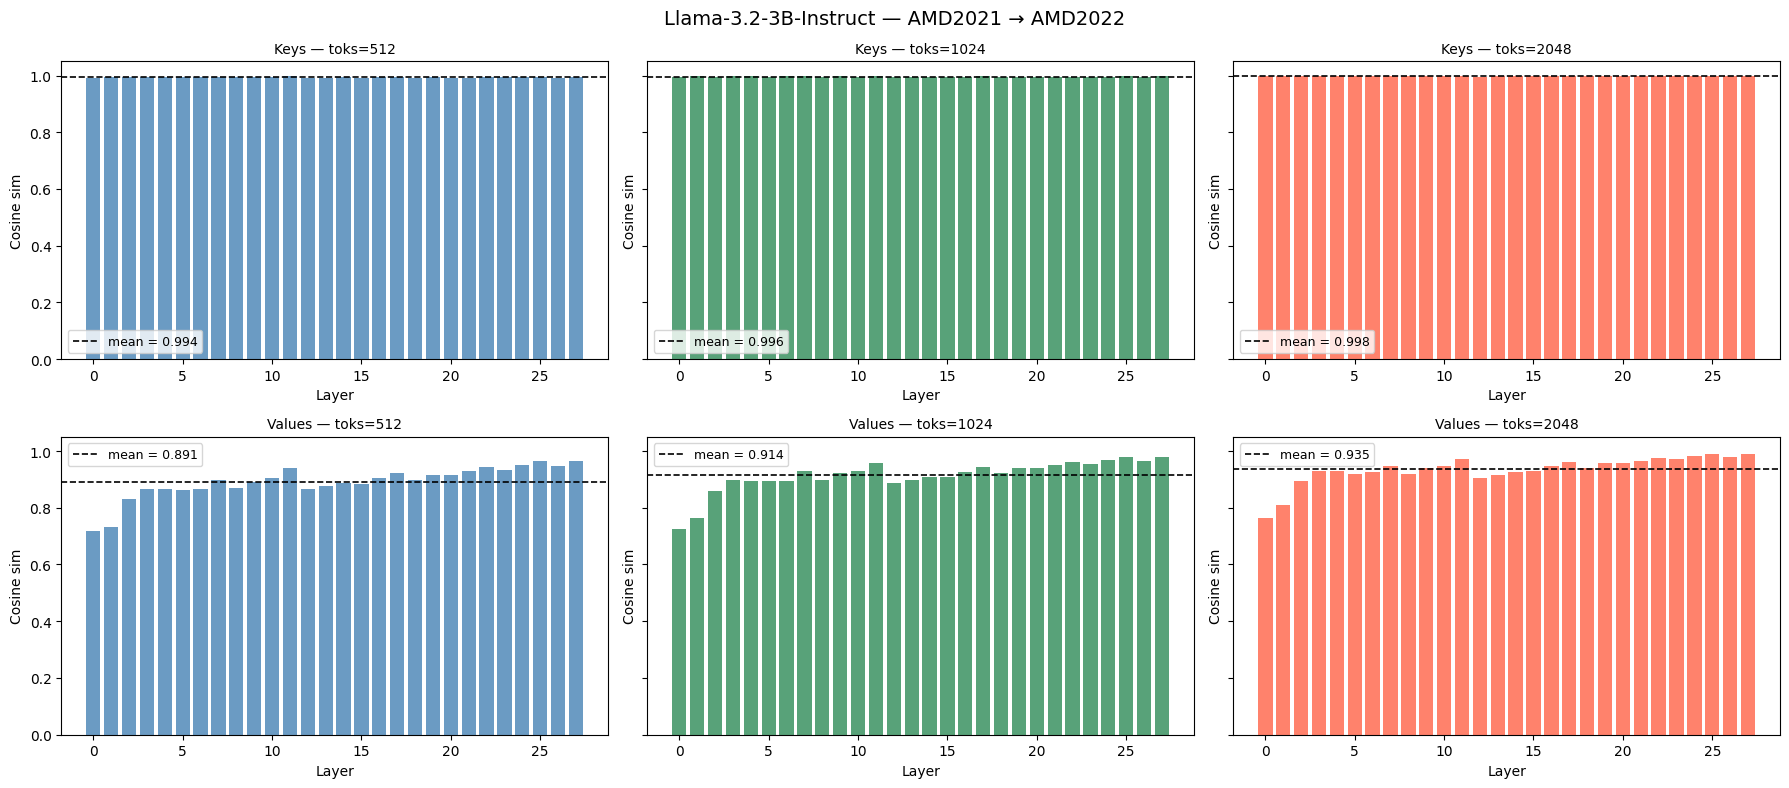

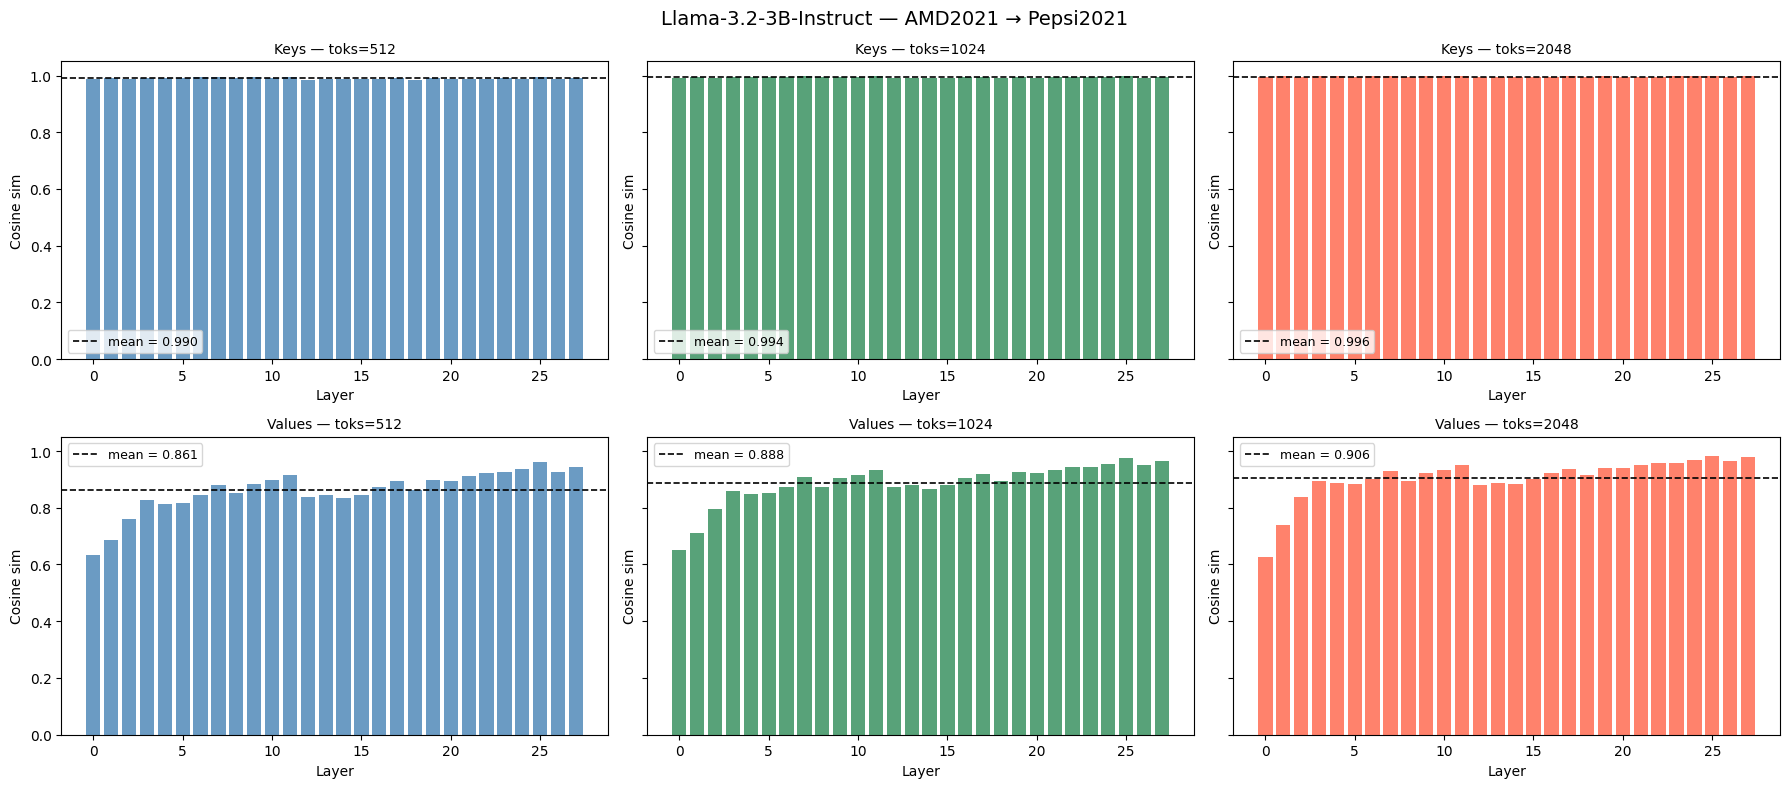

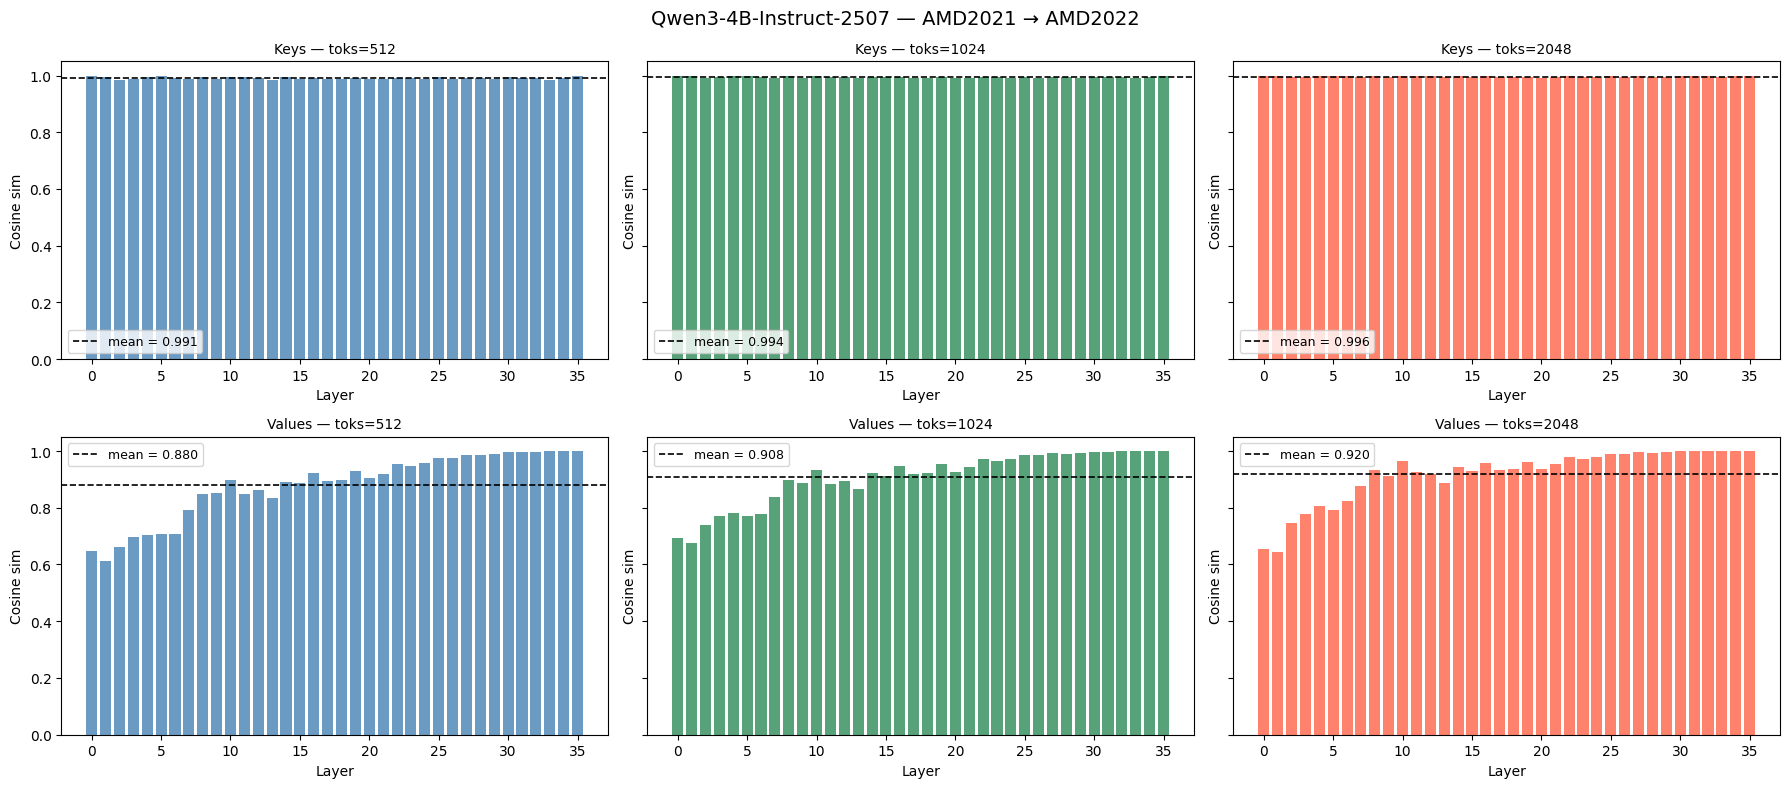

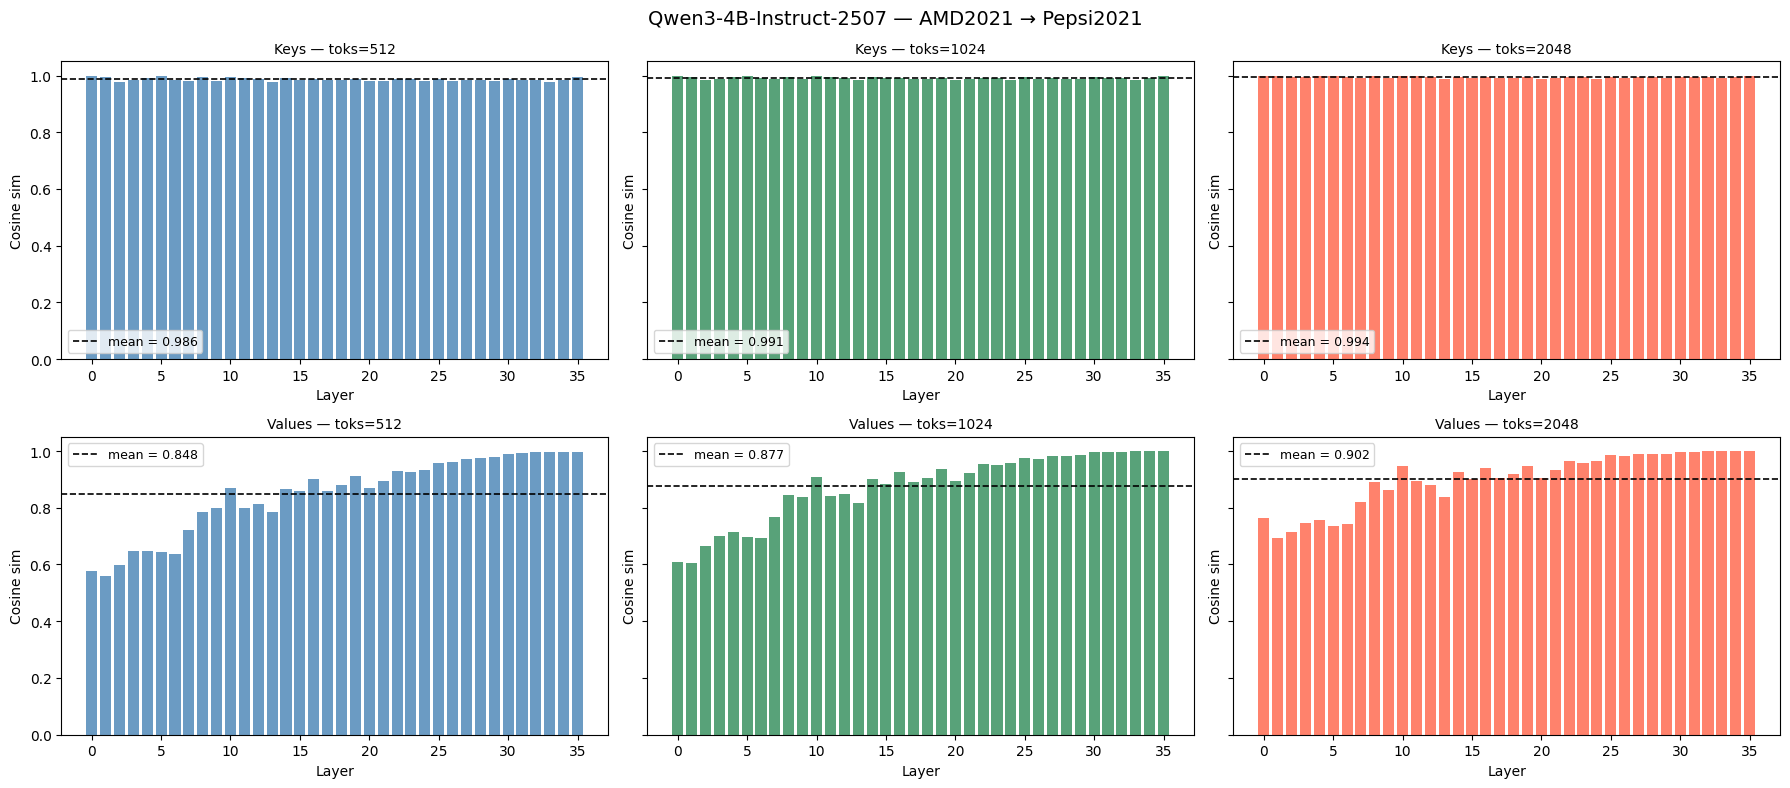

In [21]:
# Compute similarities for all pairs
sim_results = {}
for label, k1, v1, k2, v2 in results:
    key_sim, key_sim_head = between_cartridge_sim(k1, k2)
    val_sim, val_sim_head = between_cartridge_sim(v1, v2)
    sim_results[label] = {
        "key_sim": key_sim,
        "val_sim": val_sim,
        "key_sim_head": key_sim_head,
        "val_sim_head": val_sim_head,
    }

# 4 plots: (Llama/Qwen) x (AMD2022/Pepsi), each with 2 rows (Keys/Values) x 3 cols (toks)
GROUPS = [
    ("Llama-3.2-3B-Instruct — AMD2021 → AMD2022", "Llama", "AMD2022"),
    ("Llama-3.2-3B-Instruct — AMD2021 → Pepsi2021", "Llama", "Pepsi"),
    ("Qwen3-4B-Instruct-2507 — AMD2021 → AMD2022", "Qwen", "AMD2022"),
    ("Qwen3-4B-Instruct-2507 — AMD2021 → Pepsi2021", "Qwen", "Pepsi"),
]
TOK_SIZES = [512, 1024, 2048]
colors = {512: "steelblue", 1024: "seagreen", 2048: "tomato"}

for fig_title, model, target in GROUPS:
    fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True)
    fig.suptitle(fig_title, fontsize=14)

    for col, toks in enumerate(TOK_SIZES):
        label = f"{model} | AMD2021→{target}2021 | toks={toks}" if target == "Pepsi" \
                else f"{model} | AMD2021→{target} | toks={toks}"
        if label not in sim_results:
            for row in range(2):
                axes[row, col].set_visible(False)
            continue

        data = sim_results[label]
        for row, (kv, kv_title) in enumerate([("key_sim", "Keys"), ("val_sim", "Values")]):
            ax = axes[row, col]
            sim = data[kv]
            layers = np.arange(len(sim))
            ax.bar(layers, sim, color=colors[toks], alpha=0.8)
            ax.axhline(sim.mean(), color="black", linestyle="--", linewidth=1.2,
                       label=f"mean = {sim.mean():.3f}")
            ax.set_title(f"{kv_title} — toks={toks}", fontsize=10)
            ax.set_xlabel("Layer")
            ax.set_ylabel("Cosine sim")
            ax.set_ylim(0, 1.05)
            ax.legend(fontsize=9)

    plt.tight_layout()
    fname = fig_title.lower().replace(" ", "_").replace("→", "to").replace("—", "").strip("_")
    plt.show()

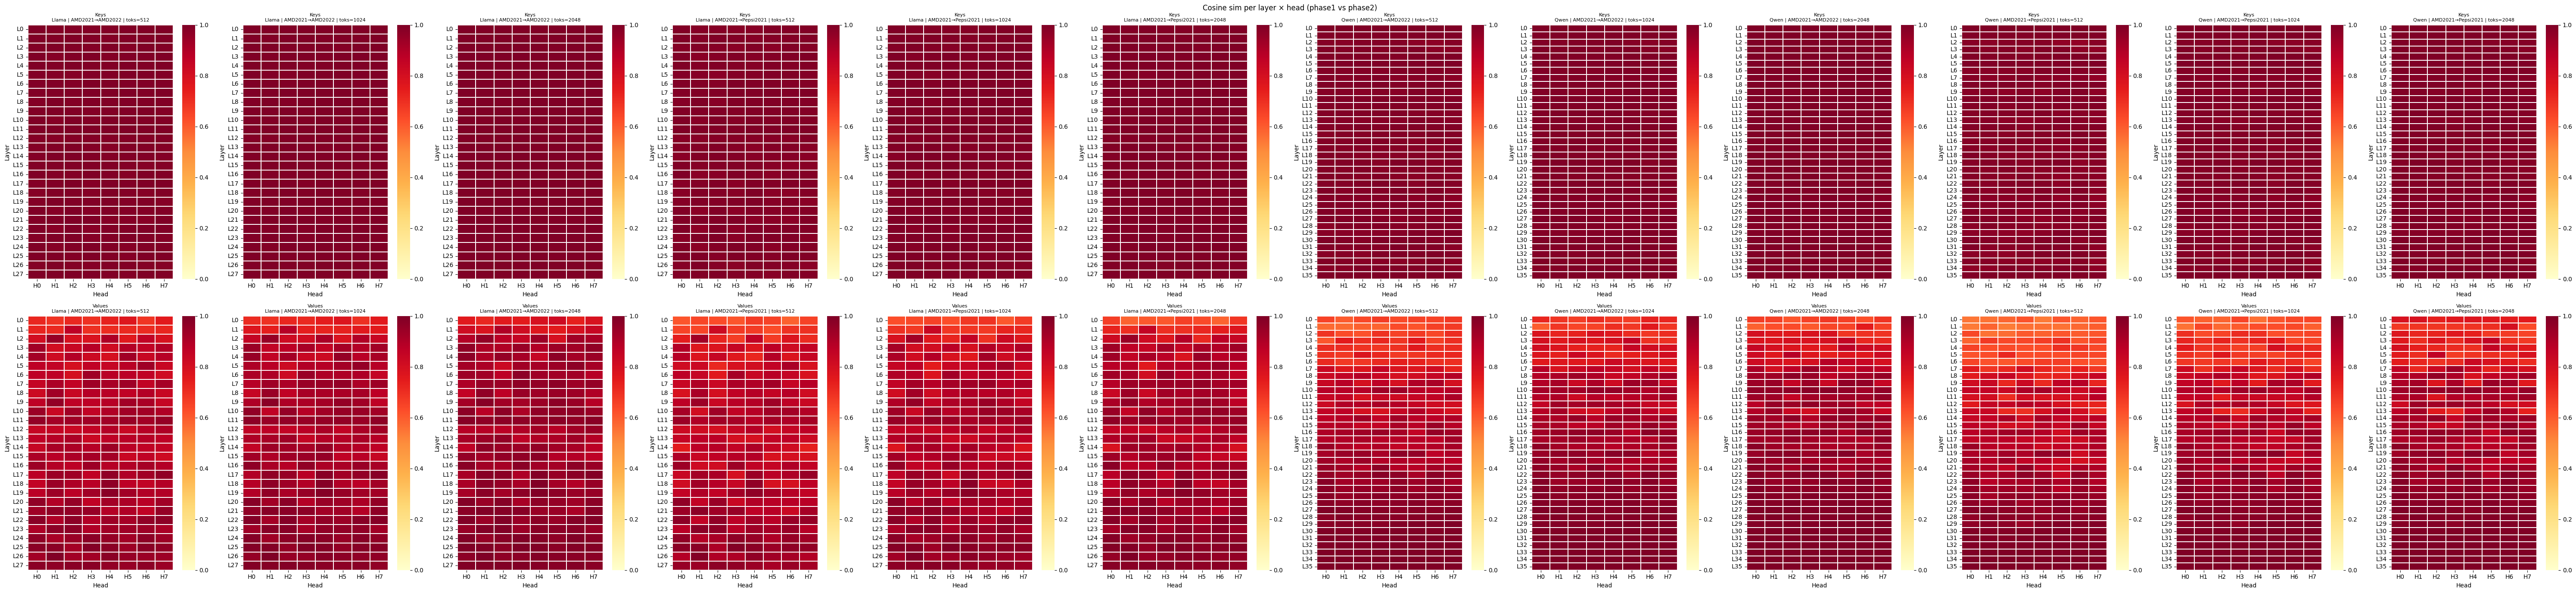

In [6]:
# Heatmaps: layer x head for keys and values, all pairs
n_pairs = len(sim_results)
fig, axes = plt.subplots(2, n_pairs, figsize=(5 * n_pairs, 14))

for col, (label, data) in enumerate(sim_results.items()):
    for row, (kv_key, title) in enumerate([("key_sim_head", "Keys"), ("val_sim_head", "Values")]):
        ax = axes[row, col]
        mat = data[kv_key]
        sns.heatmap(
            mat,
            ax=ax,
            cmap="YlOrRd",
            vmin=0, vmax=1,
            xticklabels=[f"H{h}" for h in range(mat.shape[1])],
            yticklabels=[f"L{l}" for l in range(mat.shape[0])],
            annot=False,
            linewidths=0.2,
            cbar=True,
        )
        ax.set_title(f"{title}\n{label}", fontsize=8)
        ax.set_xlabel("Head")
        ax.set_ylabel("Layer")

plt.suptitle("Cosine sim per layer × head (phase1 vs phase2)", fontsize=12)
plt.tight_layout()
plt.show()

## Layer delta analysis (most-changed layers)

For each layer, compute how much it changed from phase-1 → phase-2 (unfrozen training).

- **Cosine distance** = 1 − cosine_sim (from `between_cartridge_sim`)
- **Relative L2** = ‖v₂ − v₁‖_F / ‖v₁‖_F per layer

High-delta layers are the ones the optimizer rewrites most aggressively — candidates for freezing.

In [22]:
def layer_delta(t1, t2):
    """
    Returns:
        cos_dist  (n_layers,) — 1 - mean cosine similarity per layer
        rel_l2    (n_layers,) — Frobenius ||delta|| / ||t1|| per layer
    """
    cos_sim, _ = between_cartridge_sim(t1, t2)
    cos_dist = 1.0 - cos_sim

    t1f = t1.float()
    t2f = t2.float()
    delta_norm = (t2f - t1f).reshape(t1.shape[0], -1).norm(dim=-1)
    orig_norm  = t1f.reshape(t1.shape[0], -1).norm(dim=-1)
    rel_l2 = (delta_norm / orig_norm.clamp(min=1e-8)).numpy()

    return cos_dist, rel_l2


delta_results = {}
for label, k1, v1, k2, v2 in results:
    vcos, vl2 = layer_delta(v1, v2)
    kcos, kl2 = layer_delta(k1, k2)
    delta_results[label] = dict(
        val_cos_dist=vcos, val_rel_l2=vl2,
        key_cos_dist=kcos, key_rel_l2=kl2,
    )

print("Delta computed for all pairs.")
# Quick sanity check on one pair
label0 = list(delta_results.keys())[0]
d = delta_results[label0]
print(f"\n{label0}")
print(f"  val cosine dist range: [{d['val_cos_dist'].min():.5f}, {d['val_cos_dist'].max():.5f}]")
print(f"  val rel L2 range:      [{d['val_rel_l2'].min():.4f}, {d['val_rel_l2'].max():.4f}]")

Delta computed for all pairs.

Llama | AMD2021→AMD2022 | toks=512
  val cosine dist range: [0.03402, 0.28074]
  val rel L2 range:      [0.3075, 0.9046]


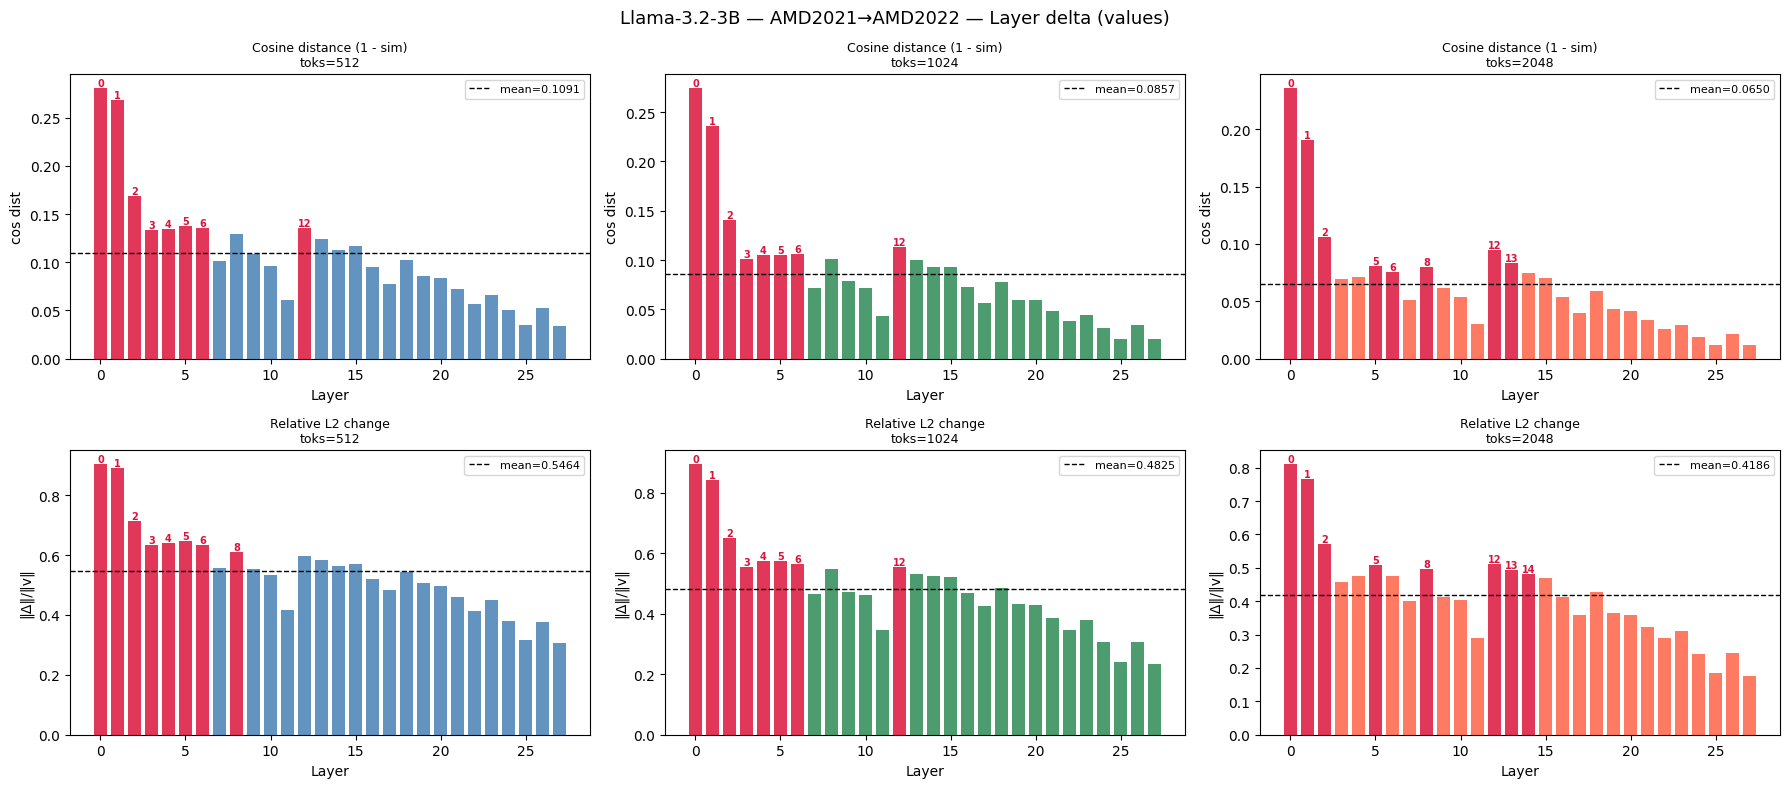

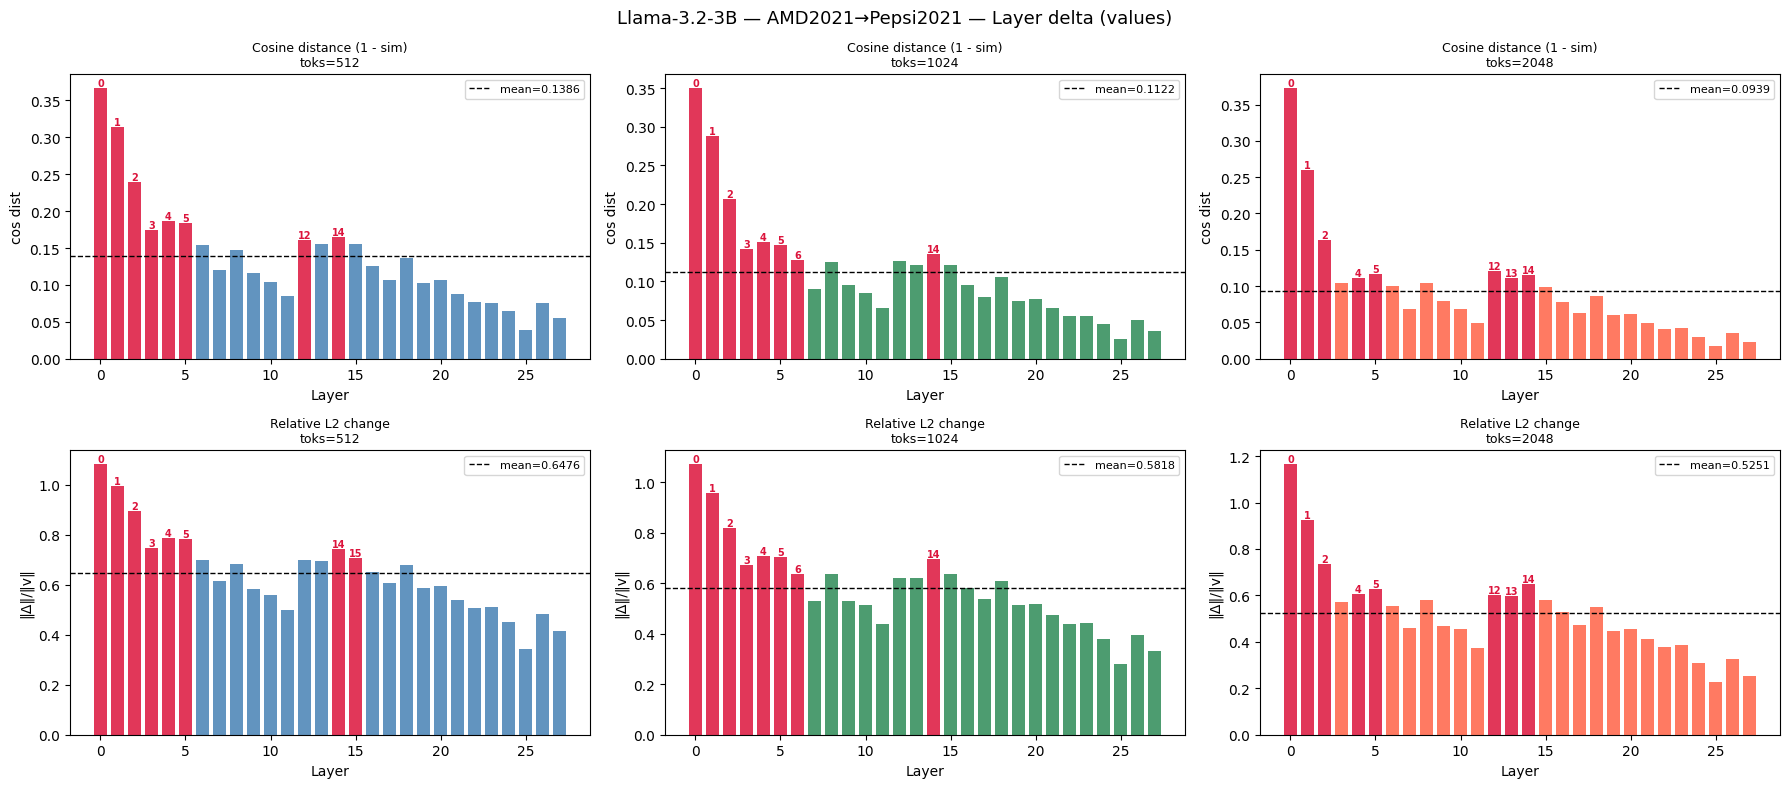

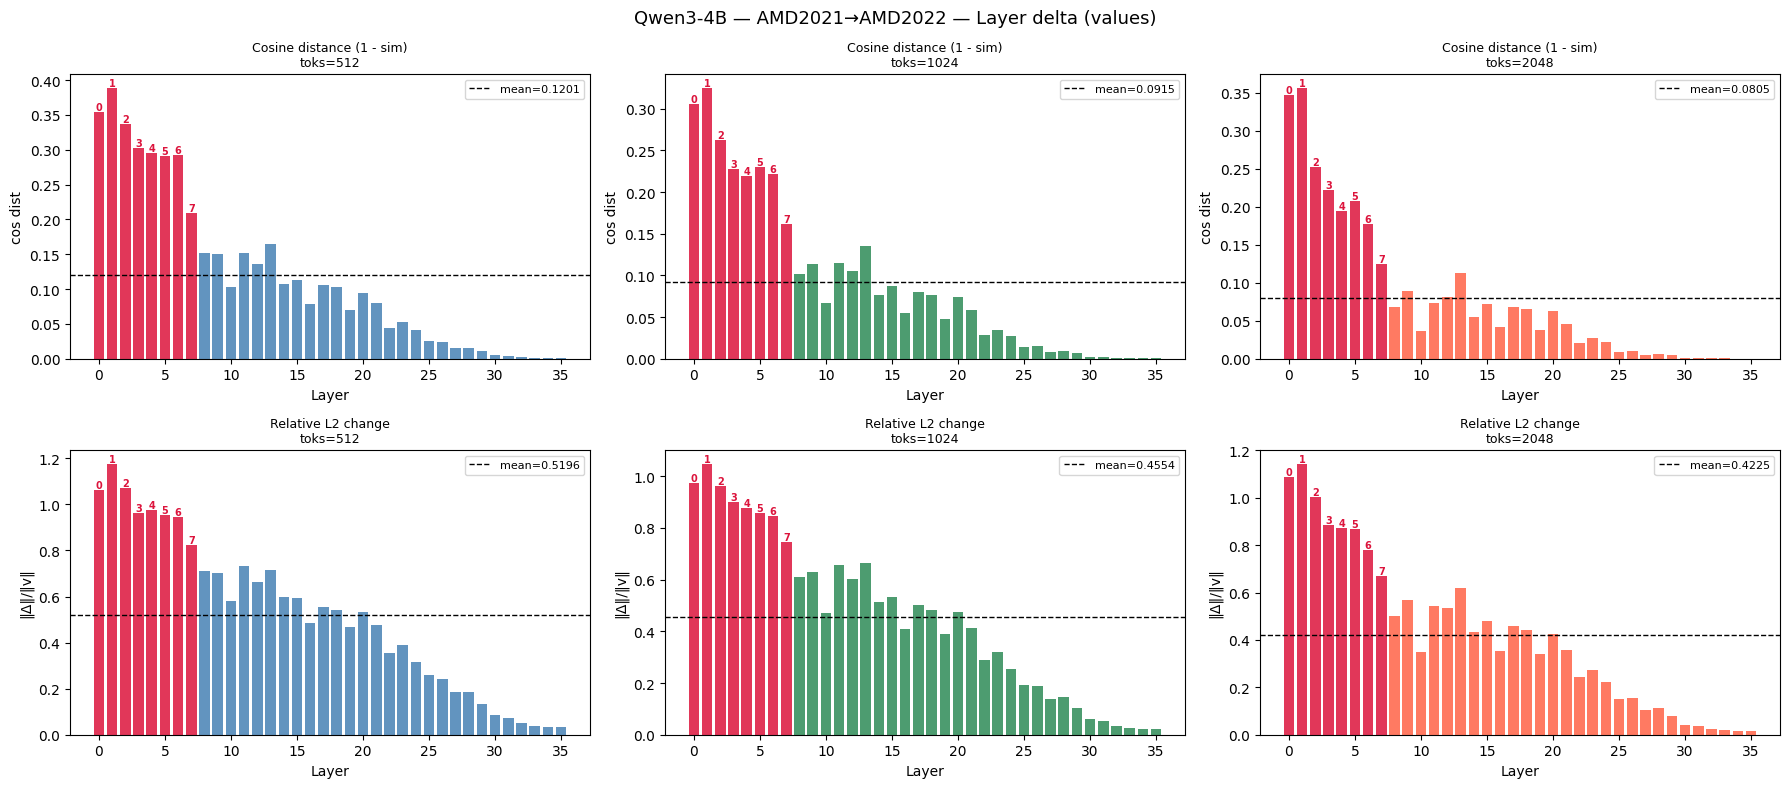

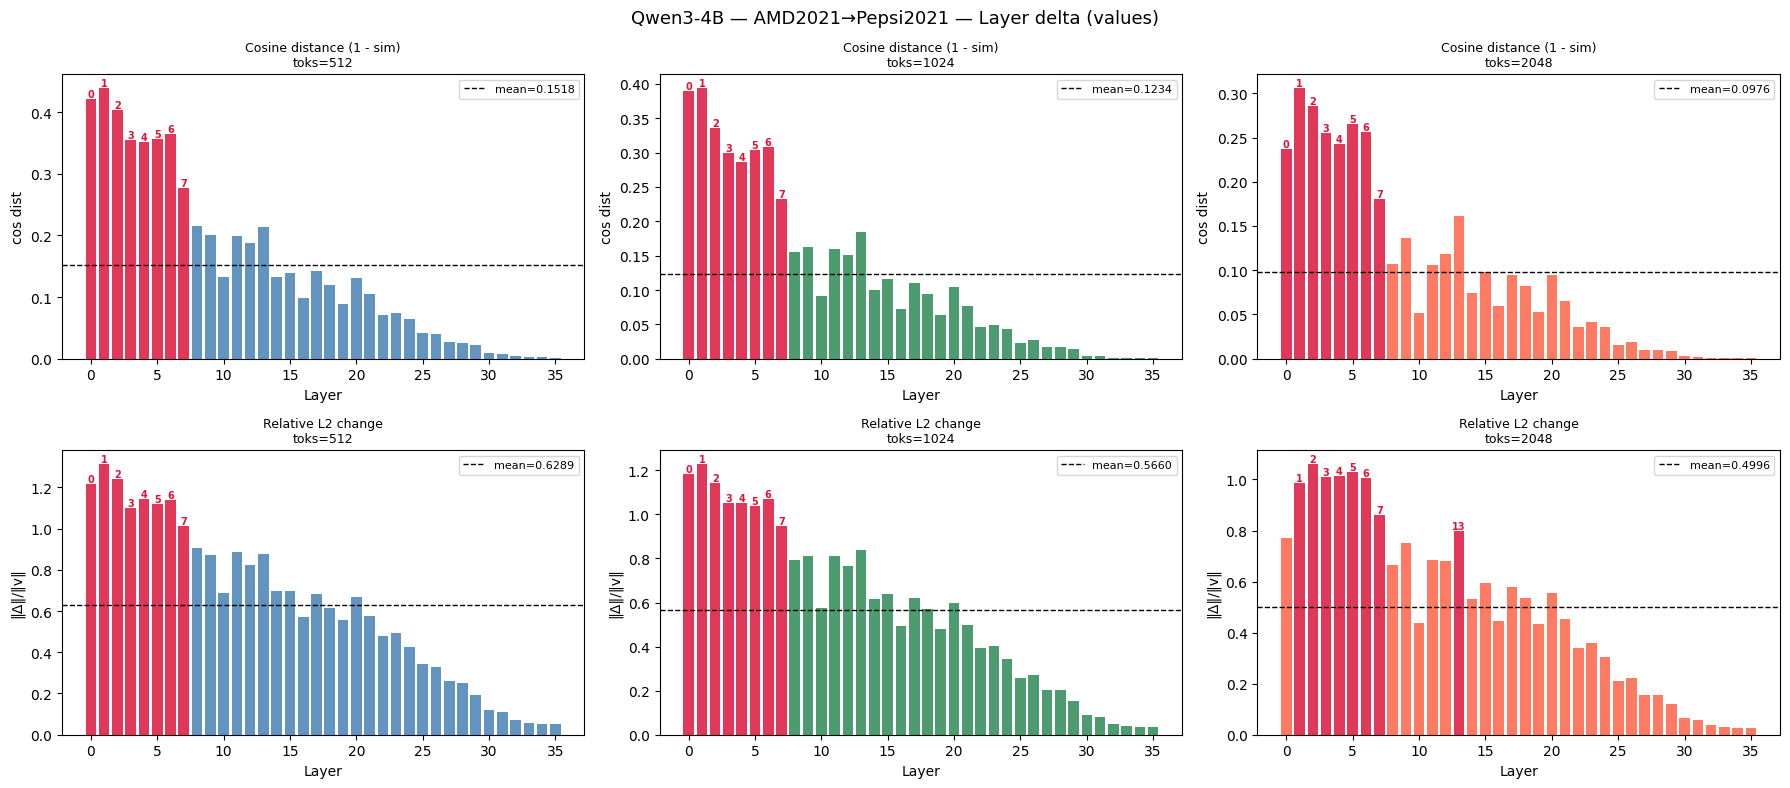

In [8]:
TOP_K = 8  # number of most-changed layers to highlight

GROUPS = [
    ("Llama-3.2-3B — AMD2021→AMD2022", "Llama", "AMD2022"),
    ("Llama-3.2-3B — AMD2021→Pepsi2021", "Llama", "Pepsi"),
    ("Qwen3-4B — AMD2021→AMD2022", "Qwen", "AMD2022"),
    ("Qwen3-4B — AMD2021→Pepsi2021", "Qwen", "Pepsi"),
]
TOK_SIZES = [512, 1024, 2048]
colors = {512: "steelblue", 1024: "seagreen", 2048: "tomato"}

for fig_title, model, target in GROUPS:
    fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=False)
    fig.suptitle(f"{fig_title} — Layer delta (values)", fontsize=13)

    for col, toks in enumerate(TOK_SIZES):
        label = (f"{model} | AMD2021→{target}2021 | toks={toks}" if target == "Pepsi"
                 else f"{model} | AMD2021→{target} | toks={toks}")
        if label not in delta_results:
            for row in range(2):
                axes[row, col].set_visible(False)
            continue

        data = delta_results[label]
        for row, (metric_key, metric_title, ylabel) in enumerate([
            ("val_cos_dist", "Cosine distance (1 - sim)", "cos dist"),
            ("val_rel_l2",   "Relative L2 change",        "‖Δ‖/‖v‖"),
        ]):
            ax = axes[row, col]
            vals = data[metric_key]
            layers = np.arange(len(vals))

            top_k_idx = np.argsort(vals)[::-1][:TOP_K]
            bar_colors = ["crimson" if i in top_k_idx else colors[toks] for i in layers]

            ax.bar(layers, vals, color=bar_colors, alpha=0.85)
            ax.axhline(vals.mean(), color="black", linestyle="--", linewidth=1.0,
                       label=f"mean={vals.mean():.4f}")
            ax.set_title(f"{metric_title}\ntoks={toks}", fontsize=9)
            ax.set_xlabel("Layer")
            ax.set_ylabel(ylabel)
            ax.legend(fontsize=8)

            # annotate top-K layer numbers
            for idx in top_k_idx:
                ax.text(idx, vals[idx], str(idx), ha="center", va="bottom",
                        fontsize=7, color="crimson", fontweight="bold")

    plt.tight_layout()
    fname = (fig_title.lower()
             .replace(" ", "_").replace("→", "to").replace("—", "")
             .replace(".", "").strip("_"))
    plt.show()

In [9]:
TOP_K = 5  #change to select more or fewer layers

print(f"Top-{TOP_K} most-changed layers (values, by cosine distance)\n")
print(f"{'Label':<50}  {'Top layers':<30}  FROZEN_LAYERS string")
print("-" * 110)
for label, data in delta_results.items():
    ranked = np.argsort(data["val_cos_dist"])[::-1]
    top_k_sorted = sorted(ranked[:TOP_K].tolist())
    frozen_str = ",".join(map(str, top_k_sorted))
    print(f"{label:<50}  {str(top_k_sorted):<30}  \"{frozen_str}\"")

Top-5 most-changed layers (values, by cosine distance)

Label                                               Top layers                      FROZEN_LAYERS string
--------------------------------------------------------------------------------------------------------------
Llama | AMD2021→AMD2022 | toks=512                  [0, 1, 2, 5, 12]                "0,1,2,5,12"
Llama | AMD2021→AMD2022 | toks=1024                 [0, 1, 2, 6, 12]                "0,1,2,6,12"
Llama | AMD2021→AMD2022 | toks=2048                 [0, 1, 2, 12, 13]               "0,1,2,12,13"
Llama | AMD2021→Pepsi2021 | toks=512                [0, 1, 2, 4, 5]                 "0,1,2,4,5"
Llama | AMD2021→Pepsi2021 | toks=1024               [0, 1, 2, 4, 5]                 "0,1,2,4,5"
Llama | AMD2021→Pepsi2021 | toks=2048               [0, 1, 2, 5, 12]                "0,1,2,5,12"
Qwen | AMD2021→AMD2022 | toks=512                   [0, 1, 2, 3, 4]                 "0,1,2,3,4"
Qwen | AMD2021→AMD2022 | toks=1024                 

In [10]:
TOP_K = 5  # change to select more or fewer layers

print(f"Top-{TOP_K} LEAST-changed layers (values, by cosine distance)\n")
print(f"{'Label':<50}  {'Top layers':<30}  FROZEN_LAYERS string")
print("-" * 110)
for label, data in delta_results.items():
    ranked = np.argsort(data["val_cos_dist"])  # ascending = least changed first
    top_k_sorted = sorted(ranked[:TOP_K].tolist())
    frozen_str = ",".join(map(str, top_k_sorted))
    print(f"{label:<50}  {str(top_k_sorted):<30}  \"{frozen_str}\"")

Top-5 LEAST-changed layers (values, by cosine distance)

Label                                               Top layers                      FROZEN_LAYERS string
--------------------------------------------------------------------------------------------------------------
Llama | AMD2021→AMD2022 | toks=512                  [22, 24, 25, 26, 27]            "22,24,25,26,27"
Llama | AMD2021→AMD2022 | toks=1024                 [22, 24, 25, 26, 27]            "22,24,25,26,27"
Llama | AMD2021→AMD2022 | toks=2048                 [22, 24, 25, 26, 27]            "22,24,25,26,27"
Llama | AMD2021→Pepsi2021 | toks=512                [23, 24, 25, 26, 27]            "23,24,25,26,27"
Llama | AMD2021→Pepsi2021 | toks=1024               [23, 24, 25, 26, 27]            "23,24,25,26,27"
Llama | AMD2021→Pepsi2021 | toks=2048               [22, 24, 25, 26, 27]            "22,24,25,26,27"
Qwen | AMD2021→AMD2022 | toks=512                   [31, 32, 33, 34, 35]            "31,32,33,34,35"
Qwen | AMD2021→AMD20

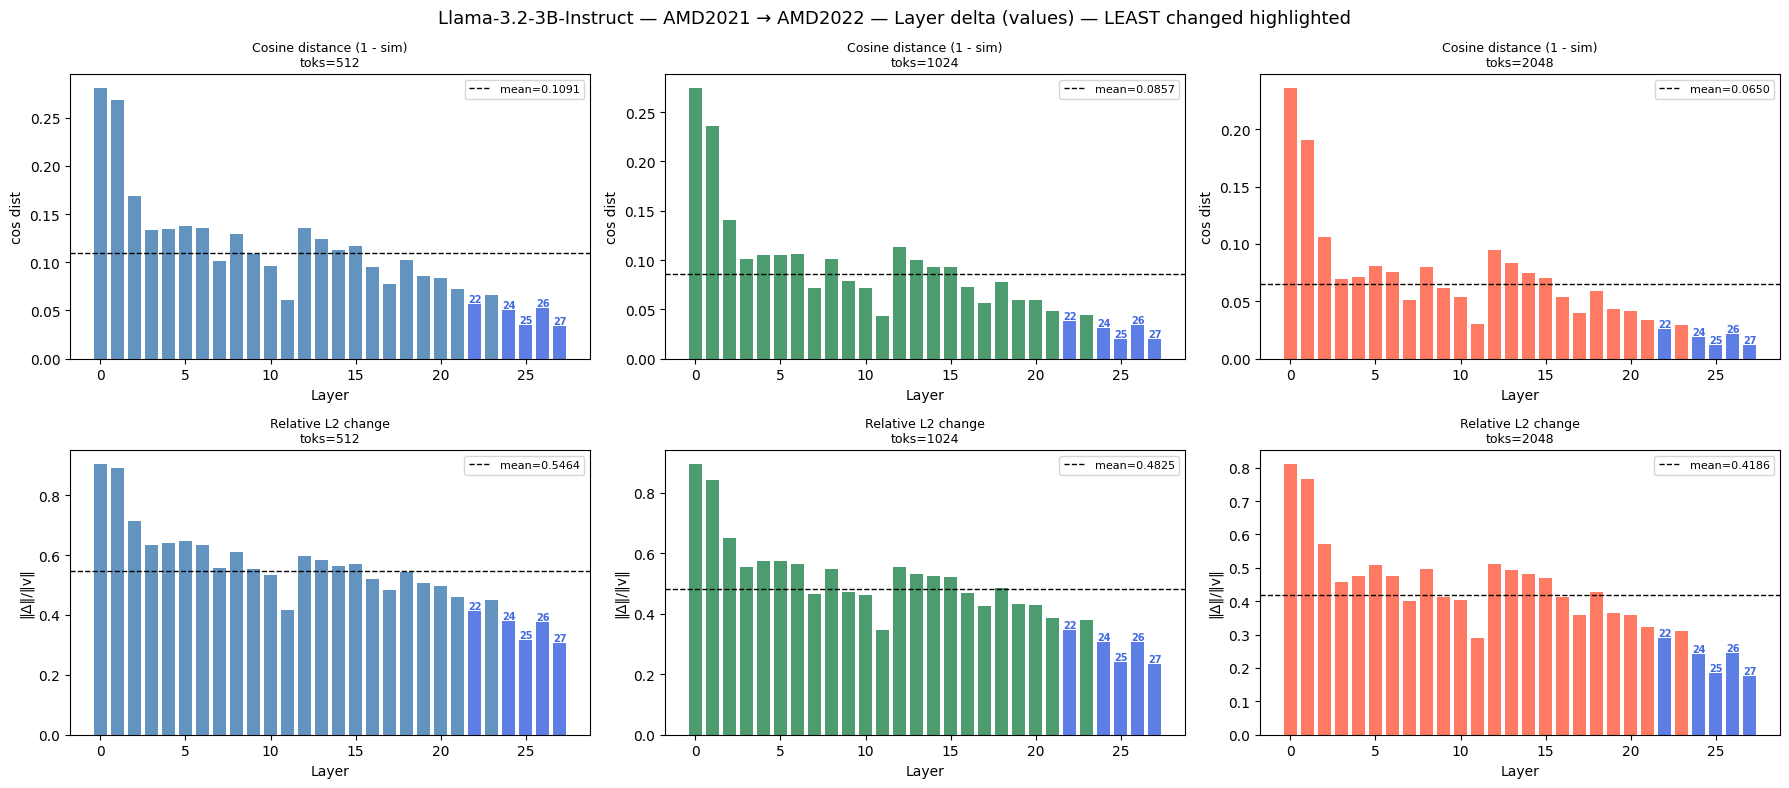

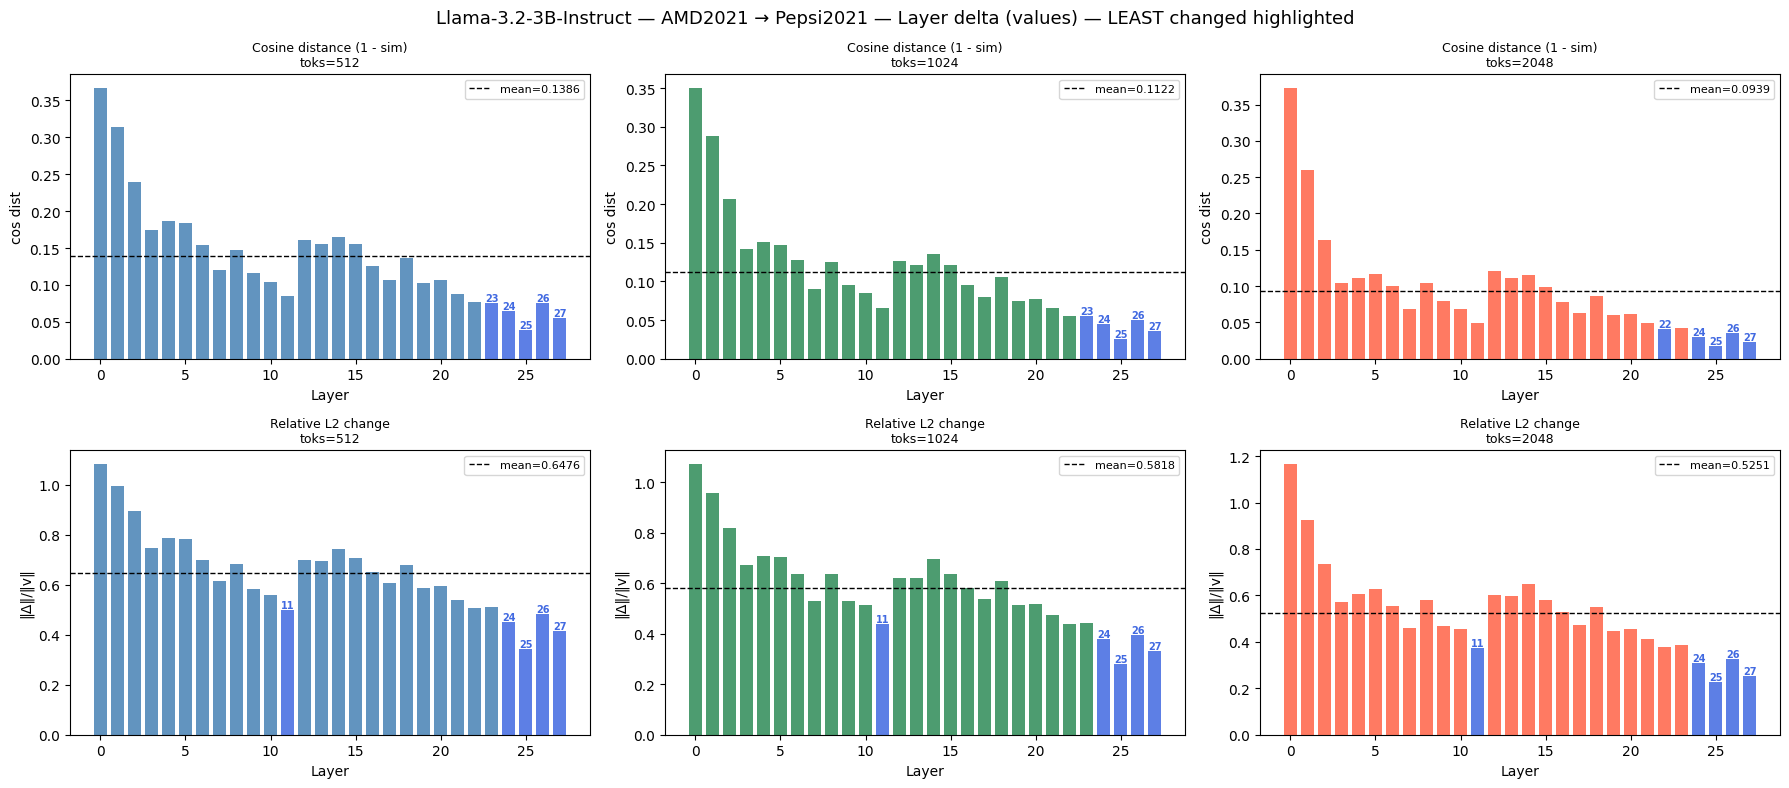

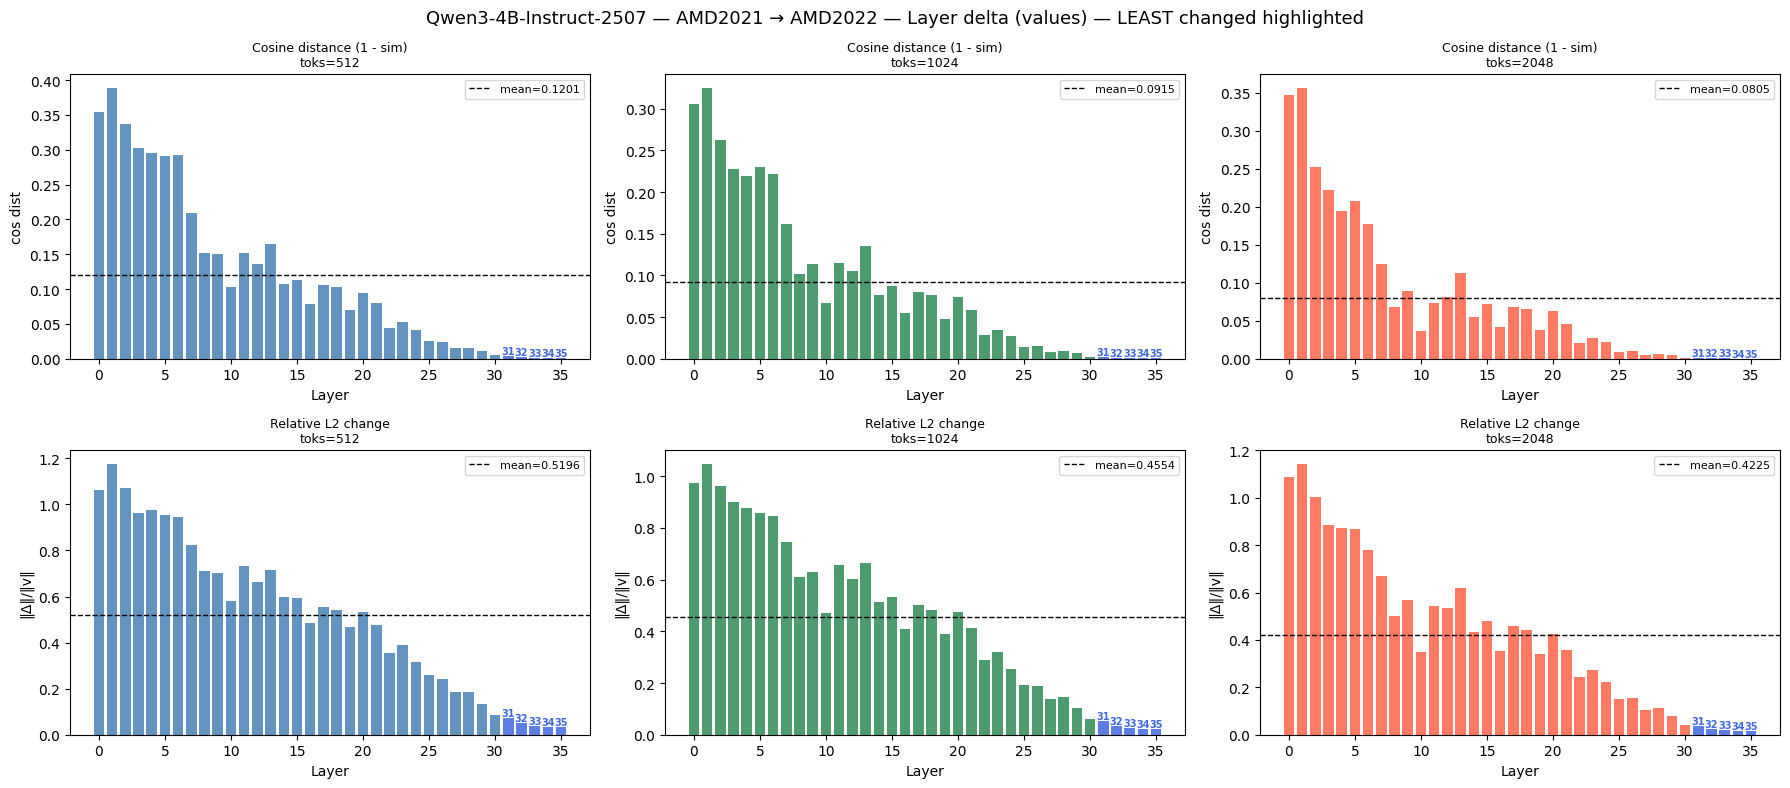

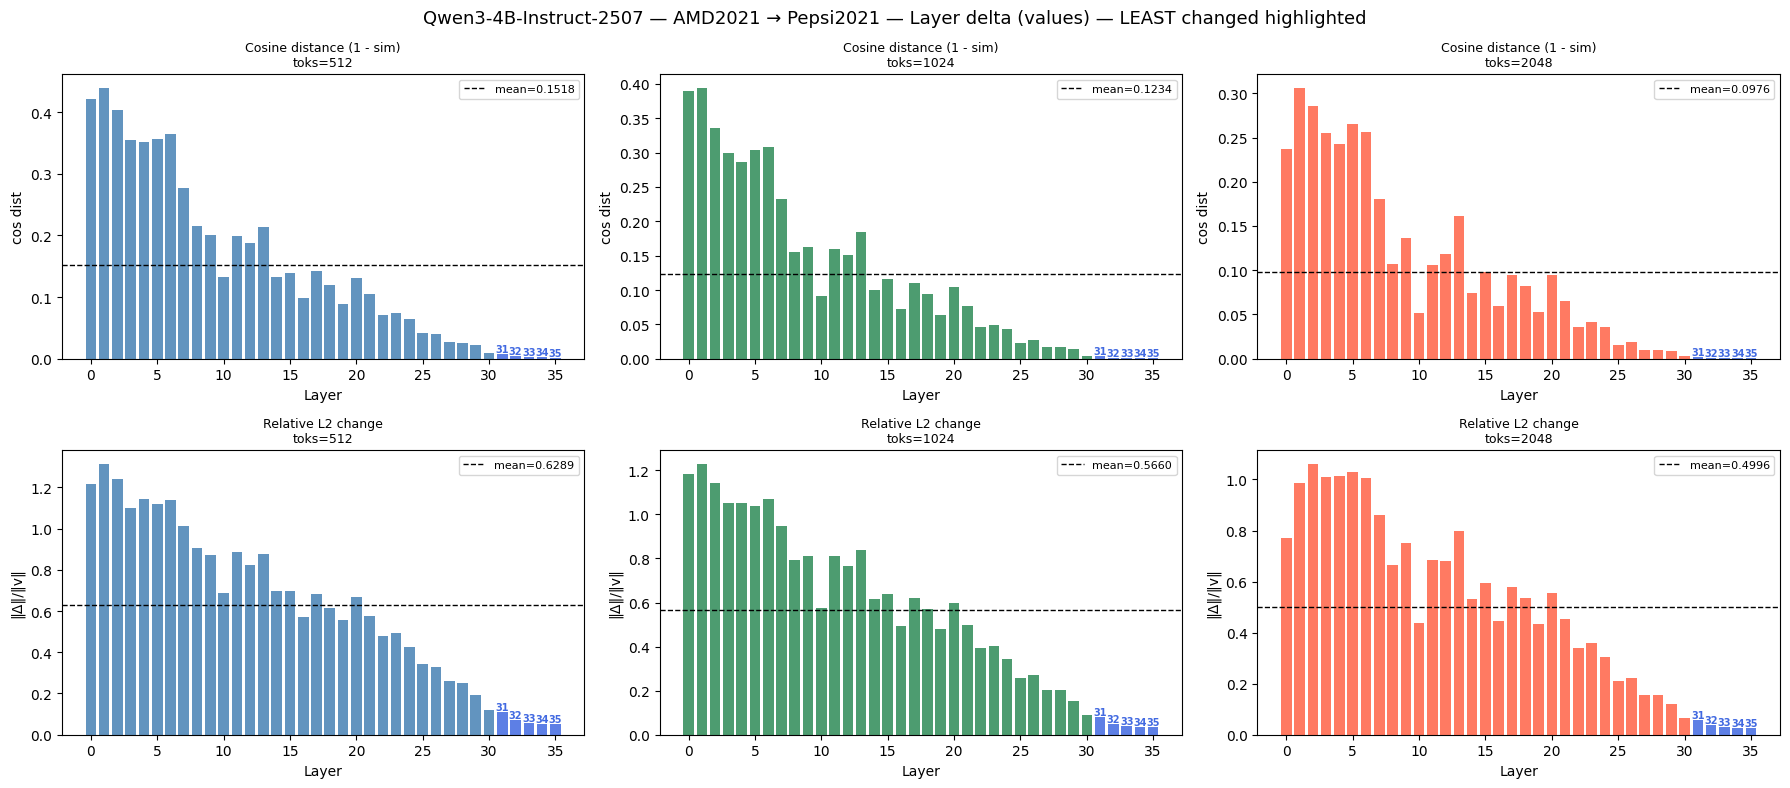

In [23]:
TOP_K = 5  # number of least-changed layers to highlight

for fig_title, model, target in GROUPS:
    fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=False)
    fig.suptitle(f"{fig_title} — Layer delta (values) — LEAST changed highlighted", fontsize=13)

    for col, toks in enumerate(TOK_SIZES):
        label = (f"{model} | AMD2021→{target}2021 | toks={toks}" if target == "Pepsi"
                 else f"{model} | AMD2021→{target} | toks={toks}")
        if label not in delta_results:
            for row in range(2):
                axes[row, col].set_visible(False)
            continue

        data = delta_results[label]
        for row, (metric_key, metric_title, ylabel) in enumerate([
            ("val_cos_dist", "Cosine distance (1 - sim)", "cos dist"),
            ("val_rel_l2",   "Relative L2 change",        "‖Δ‖/‖v‖"),
        ]):
            ax = axes[row, col]
            vals = data[metric_key]
            layers = np.arange(len(vals))

            top_k_idx = np.argsort(vals)[:TOP_K]  # ascending = least changed
            bar_colors = ["royalblue" if i in top_k_idx else colors[toks] for i in layers]

            ax.bar(layers, vals, color=bar_colors, alpha=0.85)
            ax.axhline(vals.mean(), color="black", linestyle="--", linewidth=1.0,
                       label=f"mean={vals.mean():.4f}")
            ax.set_title(f"{metric_title}\ntoks={toks}", fontsize=9)
            ax.set_xlabel("Layer")
            ax.set_ylabel(ylabel)
            ax.legend(fontsize=8)

            for idx in top_k_idx:
                ax.text(idx, vals[idx], str(idx), ha="center", va="bottom",
                        fontsize=7, color="royalblue", fontweight="bold")

    plt.tight_layout()
    fname = (fig_title.lower()
             .replace(" ", "_").replace("→", "to").replace("—", "")
             .replace(".", "").strip("_"))
    plt.show()